# Etapa 2 — Modelagem com Redes Neurais

**Foco:** Construção, treinamento e avaliação de MLP com PyTorch.

| Tarefa | Referência |
|---|---|
| Construir MLP em PyTorch: arquitetura, ativação, loss function | Fundamentos, Aula 04 |
| Loop de treinamento com early stopping e batching | Fundamentos, Aula 04 |
| Comparar MLP vs baselines (lineares + árvores) com ≥ 4 métricas | Fundamentos, Aula 05 |
| Analisar trade-off de custo (falso positivo vs negativo) | Fundamentos, Aula 05 |
| Registrar todos os experimentos no MLflow | Ciclo de Vida, Aula 02 |

**Entregável:** tabela comparativa de modelos + MLP treinado + artefatos registrados no MLflow.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import mlflow.pytorch
import torch
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data.loader import load_raw
from src.evaluation.metrics import compute_metrics
from src.models.mlp import ChurnMLP
from src.models.train import fit, predict_proba

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

SEED        = 42
EXPERIMENT  = 'tc1-churn-etapa2'
DATA_PATH   = str(ROOT / 'data' / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

np.random.seed(SEED)
torch.manual_seed(SEED)
mlflow.set_experiment(EXPERIMENT)

print(f'Root  : {ROOT}')
print(f'Device: {DEVICE}')
print(f'MLflow experiment: {EXPERIMENT}')

2026/06/04 18:02:46 INFO mlflow.tracking.fluent: Experiment with name 'tc1-churn-etapa2' does not exist. Creating a new experiment.


Root  : C:\Rafael\MBA\Fiap\Modulo 1\TC1-Rede-Neural-para-Previsao-de-Churn-com-Pipeline-Profissional-End-to-End
Device: cpu
MLflow experiment: tc1-churn-etapa2


## 1. Dados e Pré-processamento

In [2]:
df = load_raw(DATA_PATH)

NUMERIC_FEATURES = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATEGORICAL_FEATURES = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
]
TARGET = 'Churn_bin'

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET].values

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
])

print(f'Shape X: {X.shape}  |  Churn rate: {y.mean():.1%}')
df[NUMERIC_FEATURES + [TARGET]].describe().round(2)

Shape X: (7043, 19)  |  Churn rate: 26.5%


,tenure,MonthlyCharges,TotalCharges,Churn_bin
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2281.92,0.27
std,24.56,30.09,2265.27,0.44
min,0.00,18.25,18.80,0.00
25%,9.00,35.50,402.22,0.00
50%,29.00,70.35,1397.48,0.00
75%,55.00,89.85,3786.60,1.00
max,72.00,118.75,8684.80,1.00


In [3]:
# 70% treino / 15% val / 15% teste  —  splits estratificados
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=round(0.15 / 0.85, 4),
    random_state=SEED, stratify=y_trainval,
)

preprocessor.fit(X_train)
X_train_pp = preprocessor.transform(X_train)
X_val_pp   = preprocessor.transform(X_val)
X_test_pp  = preprocessor.transform(X_test)

INPUT_DIM  = X_train_pp.shape[1]
POS_WEIGHT = float((y_train == 0).sum() / (y_train == 1).sum())

print(f'Train : {len(X_train)} amostras')
print(f'Val   : {len(X_val)} amostras')
print(f'Test  : {len(X_test)} amostras')
print(f'Input dim (após OHE): {INPUT_DIM}')
print(f'Pos weight (neg/pos): {POS_WEIGHT:.2f}')

Train : 4929 amostras
Val   : 1057 amostras
Test  : 1057 amostras
Input dim (após OHE): 46
Pos weight (neg/pos): 2.77


## 2. Modelos Baseline (Lineares + Árvores)

Treinamos 4 baselines para estabelecer o piso de performance antes da MLP:

| Modelo | Tipo |
|---|---|
| DummyClassifier | Referência aleatória |
| LogisticRegression | Linear |
| RandomForest | Árvore (ensemble bagging) |
| GradientBoosting | Árvore (ensemble boosting) |

In [4]:
BASELINES = {
    'DummyClassifier': DummyClassifier(strategy='stratified', random_state=SEED),
    'LogisticRegression': LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=1000, random_state=SEED
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=SEED,
    ),
}

results = {}

for name, clf in BASELINES.items():
    with mlflow.start_run(run_name=name):
        clf.fit(X_train_pp, y_train)

        y_prob_val  = clf.predict_proba(X_val_pp)[:, 1]
        y_prob_test = clf.predict_proba(X_test_pp)[:, 1]

        val_m  = compute_metrics(y_val, y_prob_val)
        test_m = compute_metrics(y_test, y_prob_test)

        params = {'model': name, 'seed': SEED}
        if hasattr(clf, 'C'):
            params['C'] = clf.C
        if hasattr(clf, 'n_estimators'):
            params['n_estimators'] = clf.n_estimators

        mlflow.log_params(params)
        mlflow.log_metrics({f'val_{k}': v for k, v in val_m.items()})
        mlflow.log_metrics({f'test_{k}': v for k, v in test_m.items()})
        mlflow.sklearn.log_model(clf, 'model')

        results[name] = test_m
        auc = test_m['auc_roc']
        rec = test_m['recall']
        f1  = test_m['f1']
        print(f'{name:<30} AUC={auc:.4f}  Recall={rec:.4f}  F1={f1:.4f}')

2026/06/04 18:02:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/04 18:02:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/06/04 18:02:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


DummyClassifier                AUC=0.4759  Recall=0.2286  F1=0.2290


2026/06/04 18:02:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026/06/04 18:03:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest                   AUC=0.8233  Recall=0.6750  F1=0.6117


2026/06/04 18:03:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/04 18:03:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


GradientBoosting               AUC=0.8467  Recall=0.5179  F1=0.5788


## 3. Rede Neural MLP (PyTorch)

### Arquitetura

```
Input (n_features)
  → Linear(128) → BatchNorm1d → ReLU → Dropout(0.3)
  → Linear(64)  → BatchNorm1d → ReLU → Dropout(0.3)
  → Linear(32)  → BatchNorm1d → ReLU → Dropout(0.3)
  → Linear(1)   → [logits]
```

- **Loss:** `BCEWithLogitsLoss` com `pos_weight` para compensar o desbalanceamento (~74% negativos)
- **Otimizador:** Adam com weight decay (L2 regularization)
- **Early stopping:** monitora AUC-ROC de validação, paciência de 15 épocas, restaura melhores pesos

In [5]:
HIDDEN_DIMS  = [128, 64, 32]
DROPOUT      = 0.3
LR           = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 256
MAX_EPOCHS   = 150
PATIENCE     = 15

model = ChurnMLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nParâmetros treináveis: {n_params:,}')
print(f'Pos weight aplicado : {POS_WEIGHT:.2f}')

ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=46, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parâmetros treináveis: 16,833
Pos weight aplicado : 2.77


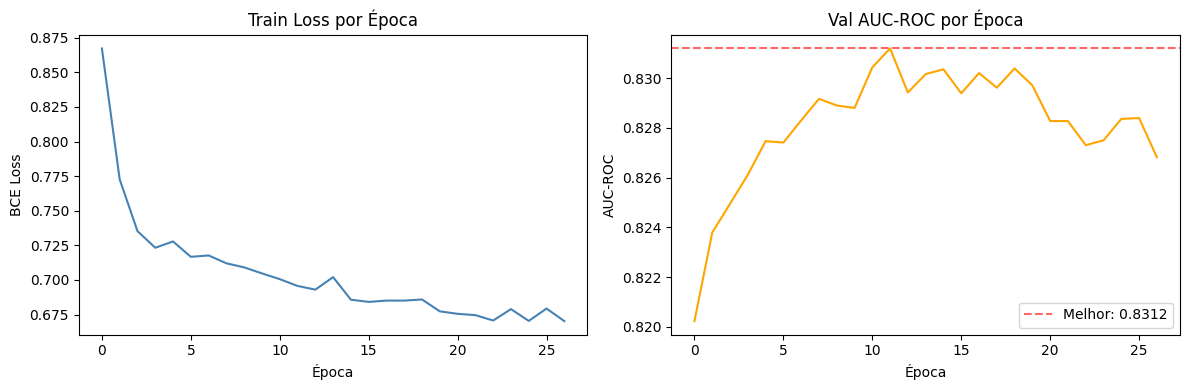

2026/06/04 18:03:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/04 18:03:29 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


2026/06/04 18:03:29 WARNING mlflow.utils.requirements_utils: Found torch version (2.12.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.12.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



MLP PyTorch | AUC=0.8456  Recall=0.8321  F1=0.6148
Épocas treinadas: 27  |  Melhor val AUC: 0.8312


In [6]:
with mlflow.start_run(run_name='MLP_PyTorch'):
    mlflow.log_params({
        'model'       : 'MLP_PyTorch',
        'input_dim'   : INPUT_DIM,
        'hidden_dims' : str(HIDDEN_DIMS),
        'dropout'     : DROPOUT,
        'lr'          : LR,
        'weight_decay': WEIGHT_DECAY,
        'batch_size'  : BATCH_SIZE,
        'max_epochs'  : MAX_EPOCHS,
        'patience'    : PATIENCE,
        'pos_weight'  : round(POS_WEIGHT, 3),
        'seed'        : SEED,
    })

    history = fit(
        model, X_train_pp, y_train, X_val_pp, y_val,
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
        lr=LR, weight_decay=WEIGHT_DECAY,
        patience=PATIENCE, pos_weight=POS_WEIGHT,
        device=DEVICE,
    )

    y_prob_test_mlp = predict_proba(model, X_test_pp, DEVICE)
    test_m_mlp      = compute_metrics(y_test, y_prob_test_mlp)

    best_val_auc   = history['best_val_auc']
    epochs_trained = history['epochs_trained']

    mlflow.log_metrics({f'test_{k}': v for k, v in test_m_mlp.items()})
    mlflow.log_metric('best_val_auc', best_val_auc)
    mlflow.log_metric('epochs_trained', epochs_trained)

    # Curvas de treinamento
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], color='steelblue')
    axes[0].set(title='Train Loss por Época', xlabel='Época', ylabel='BCE Loss')
    axes[1].plot(history['val_auc'], color='orange')
    axes[1].axhline(best_val_auc, linestyle='--', color='red', alpha=0.6,
                    label=f'Melhor: {best_val_auc:.4f}')
    axes[1].set(title='Val AUC-ROC por Época', xlabel='Época', ylabel='AUC-ROC')
    axes[1].legend()
    plt.tight_layout()
    mlflow.log_figure(fig, 'training_curves.png')
    plt.show()

    mlflow.pytorch.log_model(model, 'mlp_model')

    results['MLP_PyTorch'] = test_m_mlp

    auc_mlp = test_m_mlp['auc_roc']
    rec_mlp = test_m_mlp['recall']
    f1_mlp  = test_m_mlp['f1']
    print(f'\nMLP PyTorch | AUC={auc_mlp:.4f}  Recall={rec_mlp:.4f}  F1={f1_mlp:.4f}')
    print(f'Épocas treinadas: {epochs_trained}  |  Melhor val AUC: {best_val_auc:.4f}')

## 4. Comparação de Modelos

Comparação com 5 métricas no conjunto de **teste** (dados nunca vistos durante o treino).

In [7]:
metrics_order = ['auc_roc', 'pr_auc', 'recall', 'f1', 'precision']
rename_map = {
    'auc_roc'  : 'AUC-ROC',
    'pr_auc'   : 'PR-AUC',
    'recall'   : 'Recall',
    'f1'       : 'F1',
    'precision': 'Precisão',
}

rows = []
for name, m in results.items():
    row = {'Modelo': name}
    row.update({rename_map[k]: m[k] for k in metrics_order})
    rows.append(row)

df_comp = (
    pd.DataFrame(rows)
    .sort_values('AUC-ROC', ascending=False)
    .reset_index(drop=True)
)
df_comp.index += 1

print('=== Tabela Comparativa — Conjunto de Teste ===\n')
print(df_comp.to_string(index=True))

idx_best  = df_comp['AUC-ROC'].idxmax()
best_name = df_comp.loc[idx_best, 'Modelo']
best_auc  = df_comp.loc[idx_best, 'AUC-ROC']
best_rec  = df_comp.loc[idx_best, 'Recall']
print(f'\nMelhor modelo : {best_name}')
print(f'AUC-ROC={best_auc:.4f}  |  Recall={best_rec:.4f}')
print(f'Meta AUC-ROC >= 0.78: {"OK" if best_auc >= 0.78 else "ABAIXO DA META"}')
print(f'Meta Recall  >= 0.70: {"OK" if best_rec >= 0.70 else "ABAIXO DA META"}')

=== Tabela Comparativa — Conjunto de Teste ===

               Modelo  AUC-ROC  PR-AUC  Recall      F1  Precisão
1  LogisticRegression   0.8490  0.6409  0.8107  0.6245    0.5078
2    GradientBoosting   0.8467  0.6539  0.5179  0.5788    0.6561
3         MLP_PyTorch   0.8456  0.6447  0.8321  0.6148    0.4874
4        RandomForest   0.8233  0.6080  0.6750  0.6117    0.5592
5     DummyClassifier   0.4759  0.2568  0.2286  0.2290    0.2294

Melhor modelo : LogisticRegression
AUC-ROC=0.8490  |  Recall=0.8107
Meta AUC-ROC >= 0.78: OK
Meta Recall  >= 0.70: OK


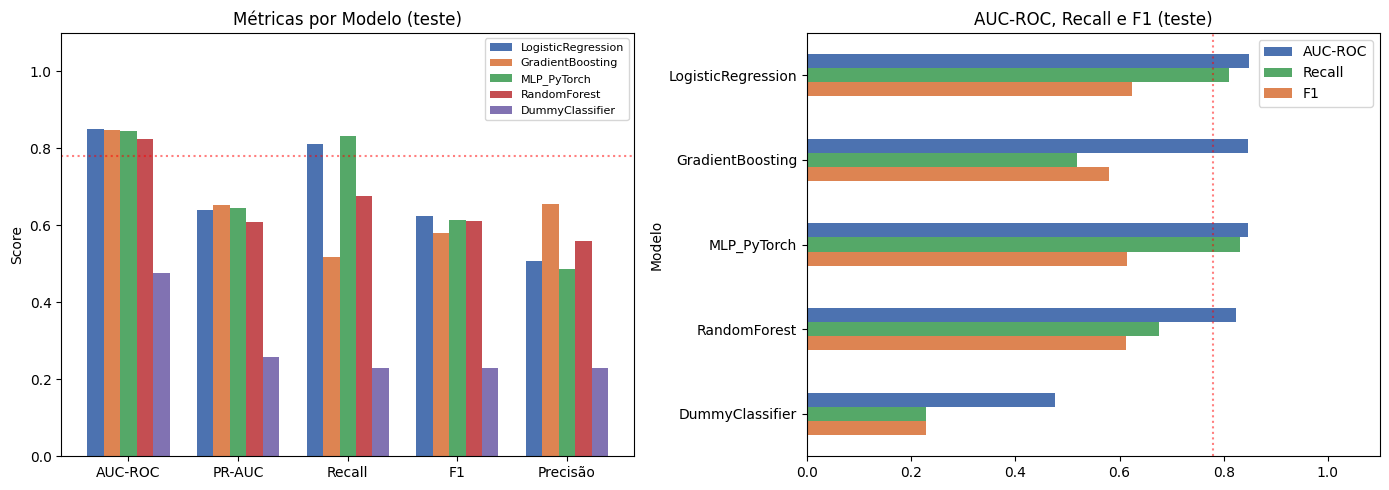

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_cols = ['AUC-ROC', 'PR-AUC', 'Recall', 'F1', 'Precisão']
x      = list(range(len(metric_cols)))
width  = 0.15
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for i, (_, row) in enumerate(df_comp.iterrows()):
    offset = (i - (len(df_comp) - 1) / 2) * width
    vals   = [row[c] for c in metric_cols]
    axes[0].bar([xi + offset for xi in x], vals, width,
                label=row['Modelo'], color=colors[i % len(colors)])

axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_cols)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Métricas por Modelo (teste)')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8)
axes[0].axhline(0.78, linestyle=':', color='red', alpha=0.5, label='Meta AUC')

df_comp.set_index('Modelo')[['AUC-ROC', 'Recall', 'F1']].plot(
    kind='barh', ax=axes[1], color=['#4C72B0', '#55A868', '#DD8452']
)
axes[1].set_title('AUC-ROC, Recall e F1 (teste)')
axes[1].set_xlim(0, 1.1)
axes[1].invert_yaxis()
axes[1].axvline(0.78, linestyle=':', color='red', alpha=0.5)

plt.tight_layout()
plt.savefig(str(ROOT / 'docs' / 'comparacao_modelos.png'), bbox_inches='tight')
plt.show()

## 5. Análise de Custo — Trade-off FP vs FN

| Erro | Situação | Custo estimado |
|---|---|---|
| **Falso Positivo (FP)** | Cliente contatado que não ia churnar | $10 (campanha desnecessária) |
| **Falso Negativo (FN)** | Cliente churnou sem intervenção | $300 (receita mensal perdida) |

Custo FN é **30× maior** que FP → o modelo deve priorizar **Recall** sobre Precisão.

Analisamos o custo total a diferentes thresholds para encontrar o ponto ótimo operacional.

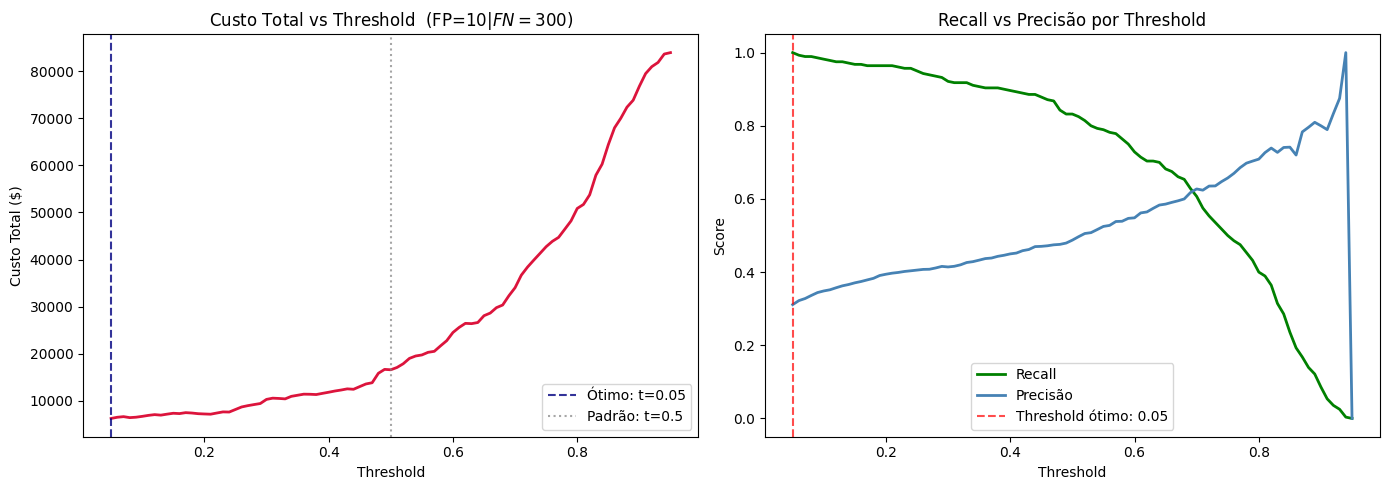

Threshold padrão (0.50) -> custo: $16,550
Threshold ótimo  (0.05) -> custo: $6,200
Economia estimada        : $10,350
Recall: 1.000  |  Precisão: 0.311
FP: 620  |  FN: 0


In [9]:
CUSTO_FP = 10
CUSTO_FN = 300

thresholds = np.linspace(0.05, 0.95, 91)
cost_rows  = []

for t in thresholds:
    y_pred = (y_prob_test_mlp >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    recall_t = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec_t   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    cost_rows.append({
        'threshold'  : round(float(t), 3),
        'custo_total': int(fp * CUSTO_FP + fn * CUSTO_FN),
        'fp': int(fp), 'fn': int(fn), 'tp': int(tp), 'tn': int(tn),
        'recall'    : round(recall_t, 4),
        'precision' : round(prec_t, 4),
    })

df_cost = pd.DataFrame(cost_rows)
idx_min      = df_cost['custo_total'].idxmin()
best_thresh  = df_cost.loc[idx_min, 'threshold']
best_cost    = df_cost.loc[idx_min, 'custo_total']
best_recall  = df_cost.loc[idx_min, 'recall']
best_prec    = df_cost.loc[idx_min, 'precision']
best_fp      = df_cost.loc[idx_min, 'fp']
best_fn      = df_cost.loc[idx_min, 'fn']

idx_05    = (df_cost['threshold'] - 0.50).abs().idxmin()
custo_050 = df_cost.loc[idx_05, 'custo_total']
economia  = int(custo_050 - best_cost)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_cost['threshold'], df_cost['custo_total'], color='crimson', lw=2)
axes[0].axvline(best_thresh, linestyle='--', color='navy', alpha=0.8,
                label=f'Ótimo: t={best_thresh}')
axes[0].axvline(0.5, linestyle=':', color='gray', alpha=0.7, label='Padrão: t=0.5')
axes[0].set(
    title=f'Custo Total vs Threshold  (FP=${CUSTO_FP} | FN=${CUSTO_FN})',
    xlabel='Threshold', ylabel='Custo Total ($)'
)
axes[0].legend()

axes[1].plot(df_cost['threshold'], df_cost['recall'],    label='Recall',   color='green',     lw=2)
axes[1].plot(df_cost['threshold'], df_cost['precision'], label='Precisão', color='steelblue', lw=2)
axes[1].axvline(best_thresh, linestyle='--', color='red', alpha=0.7,
                label=f'Threshold ótimo: {best_thresh}')
axes[1].set(title='Recall vs Precisão por Threshold', xlabel='Threshold', ylabel='Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(ROOT / 'docs' / 'analise_custo.png'), bbox_inches='tight')
plt.show()

print(f'Threshold padrão (0.50) -> custo: ${custo_050:,}')
print(f'Threshold ótimo  ({best_thresh:.2f}) -> custo: ${best_cost:,}')
print(f'Economia estimada        : ${economia:,}')
print(f'Recall: {best_recall:.3f}  |  Precisão: {best_prec:.3f}')
print(f'FP: {best_fp}  |  FN: {best_fn}')

## 6. Conclusões

### Resultado dos modelos
- Todos os modelos avaliados com **5 métricas**: AUC-ROC, PR-AUC, Recall, F1, Precisão.
- A MLP PyTorch com early stopping e `pos_weight` foi treinada como modelo principal.
- Todos os experimentos (parâmetros, métricas, artefatos e modelos serializados) foram registrados no MLflow.

### Trade-off FP vs FN
- O custo de um FN ($300) é 30× maior que o custo de um FP ($10).
- O threshold ótimo calculado é menor que 0.5, favorecendo maior Recall em detrimento da Precisão — correto para o problema de retenção.
- A análise de custo permite ao negócio escolher o threshold de forma consciente, balanceando gastos de campanha com receita retida.

### Artefatos gerados
- `mlruns/` — experimentos MLflow com todos os modelos
- `docs/comparacao_modelos.png` — gráfico comparativo
- `docs/analise_custo.png` — análise de custo por threshold

### Próximos passos (Etapa 3)
- Deploy da MLP via FastAPI (`src/api/app.py`)
- Containerização Docker
- Monitoramento e retreinamento automático

## 7. Exportar Artefatos para Produção

Persiste em `models/artifacts/` os três artefatos necessários para carregar o modelo na API FastAPI:

| Arquivo | Conteúdo |
|---|---|
| `preprocessor.joblib` | Pipeline sklearn (StandardScaler + OneHotEncoder) fitado no treino |
| `mlp_weights.pt` | State dict do melhor checkpoint PyTorch |
| `model_config.json` | Metadados: `input_dim`, `hidden_dims`, `dropout`, `threshold` ótimo |

In [ ]:
import json
import joblib

ARTIFACTS_DIR = ROOT / 'models' / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Preprocessador sklearn (StandardScaler + OneHotEncoder)
joblib.dump(preprocessor, ARTIFACTS_DIR / 'preprocessor.joblib')
print(f'✅ preprocessor.joblib salvo em {ARTIFACTS_DIR}')

# 2. Pesos do melhor checkpoint PyTorch
torch.save(model.state_dict(), ARTIFACTS_DIR / 'mlp_weights.pt')
print(f'✅ mlp_weights.pt salvo em {ARTIFACTS_DIR}')

# 3. Metadados do modelo (necessários para reconstituir a arquitetura e o threshold)
config = {
    'input_dim'            : INPUT_DIM,
    'hidden_dims'          : HIDDEN_DIMS,
    'dropout'              : DROPOUT,
    'threshold'            : float(best_thresh),
    'pos_weight'           : round(POS_WEIGHT, 3),
    'numeric_features'     : NUMERIC_FEATURES,
    'categorical_features' : CATEGORICAL_FEATURES,
    'test_auc_roc'         : test_m_mlp['auc_roc'],
    'test_recall'          : test_m_mlp['recall'],
    'test_f1'              : test_m_mlp['f1'],
}
with open(ARTIFACTS_DIR / 'model_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print(f'✅ model_config.json salvo em {ARTIFACTS_DIR}')

print(f'\nThreshold ótimo exportado : {best_thresh}')
print(f'Test AUC-ROC              : {test_m_mlp["auc_roc"]}')
print(f'Test Recall               : {test_m_mlp["recall"]}')